In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
cols_to_keep = [
    'year',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn',
    'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
    'Tot_HCPCS_Cds',
    'Tot_Benes',
    'Tot_Srvcs',
    'Tot_Sbmtd_Chrg',
    'Tot_Mdcr_Alowd_Amt',
    'Tot_Mdcr_Pymt_Amt',
    'Bene_Avg_Age',
    'Bene_Avg_Risk_Scre'
]

df= pd.read_csv("Dataset_only_related_cols.csv", usecols=cols_to_keep)

In [16]:
df.head()

,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year
0,MD,PrimaryCare,Y,22,665,1648.0,395335.0,146521.84,116332.66,74,2.1114,2013
1,IL,LabPathology,Y,13,3939,7517.0,1211425.0,282079.49,217960.62,76,1.0156,2013
2,OH,Anesthesia,Y,42,144,661.0,197224.0,63334.30,49752.77,63,1.5662,2013
3,PA,PrimaryCare,Y,37,436,1683.0,240818.0,174786.95,138741.21,76,1.8967,2013
4,OH,OBGYN,Y,33,63,320.0,31637.0,13176.47,10320.43,56,1.1882,2013


In [17]:
df_sample = (
    df.groupby("year", group_keys=False)
      .apply(lambda x: x.sample(n=min(len(x), 20000), random_state=42).assign(year=x.name))
      .reset_index(drop=True)
)

In [18]:
print(df['year'].value_counts().sort_index())       # original counts
print(df_sample['year'].value_counts().sort_index()) # sampled counts

year
2013     956251
2014     986657
2015    1019377
2016    1053958
2017    1088687
2018    1121462
2019    1155870
2020    1161542
2021    1198754
2022    1230293
2023    1259343
Name: count, dtype: int64
year
2013    20000
2014    20000
2015    20000
2016    20000
2017    20000
2018    20000
2019    20000
2020    20000
2021    20000
2022    20000
2023    20000
Name: count, dtype: int64


In [10]:
bad_rows = df_sample[df_sample.isna().any(axis=1) | (df_sample == '#').any(axis=1)]
print(bad_rows.head())
print("Number of rows with NaN or '#':", len(bad_rows))

Empty DataFrame
Columns: [Rndrng_Prvdr_State_Abrvtn, Rndrng_Prvdr_Type, Rndrng_Prvdr_Mdcr_Prtcptg_Ind, Tot_HCPCS_Cds, Tot_Benes, Tot_Srvcs, Tot_Sbmtd_Chrg, Tot_Mdcr_Alowd_Amt, Bene_Avg_Age, Bene_Avg_Risk_Scre, year]
Index: []
Number of rows with NaN or '#': 0


In [19]:
df_sample = df_sample.copy()


In [20]:
df_sample['Tot_Mdcr_Pymt_Amt_log'] = np.log1p(df_sample['Tot_Mdcr_Pymt_Amt'])

In [21]:
string_cols = df_sample.select_dtypes(include=['object']).columns.tolist()
print("String columns:", string_cols)

# one-hot encode them
df_encoded = pd.get_dummies(df_sample, columns=string_cols, drop_first=False)

print(df_encoded.shape)
print(df_encoded.head())

String columns: ['Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind']
(220000, 90)
   Tot_HCPCS_Cds  Tot_Benes  Tot_Srvcs  Tot_Sbmtd_Chrg  Tot_Mdcr_Alowd_Amt  \
0              6         59      766.0          5875.0             5644.91   
1             11         75      158.0         46675.0            17579.90   
2             12         64      181.0         43460.0            16256.91   
3              7         25       99.0         15155.0             9945.30   
4             70       1019     3284.0        630699.0           264704.32   

   Tot_Mdcr_Pymt_Amt  Bene_Avg_Age  Bene_Avg_Risk_Scre  year  \
0            3325.27            73              0.7680  2013   
1           13911.10            67              1.3046  2013   
2           12925.64            65              2.1357  2013   
3            7286.85            75              0.8652  2013   
4          203962.39            72              1.5869  2013   

   Tot_Mdcr_Pymt_Amt_log  ...  Rn

/tmp/ipykernel_43811/397641307.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_sample.select_dtypes(include=['object']).columns.tolist()


In [22]:
train_df = df_encoded[df_encoded['year'].between(2013, 2020)].copy()
val_df   = df_encoded[df_encoded['year'] == 2021].copy()
test_df  = df_encoded[df_encoded['year'].between(2022, 2023)].copy()

target = 'Tot_Mdcr_Pymt_Amt_log'

In [23]:
# drop leakage columns
drop_cols = [target, 'Tot_Mdcr_Pymt_Amt', 'year']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

print("Train:", X_train.shape, y_train.shape)
print("val :", X_val.shape, y_val.shape)
# drop leakage columns
drop_cols = [target, 'Tot_Mdcr_Pymt_Amt', 'year']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

print("Train:", X_train.shape, y_train.shape)
print("val :", X_val.shape, y_val.shape)

Train: (160000, 87) (160000,)
val : (20000, 87) (20000,)
Train: (160000, 87) (160000,)
val : (20000, 87) (20000,)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# fit model
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred_log = lr.predict(X_val)

In [26]:
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
mae_log = mean_absolute_error(y_val, y_pred_log)
r2_log = r2_score(y_val, y_pred_log)

print("RMSE (log scale):", rmse_log)
print("MAE  (log scale):", mae_log)
print("R^2  (log scale):", r2_log)

RMSE (log scale): 1.0607912224314726
MAE  (log scale): 0.8095863275192212
R^2  (log scale): 0.4909934677025989


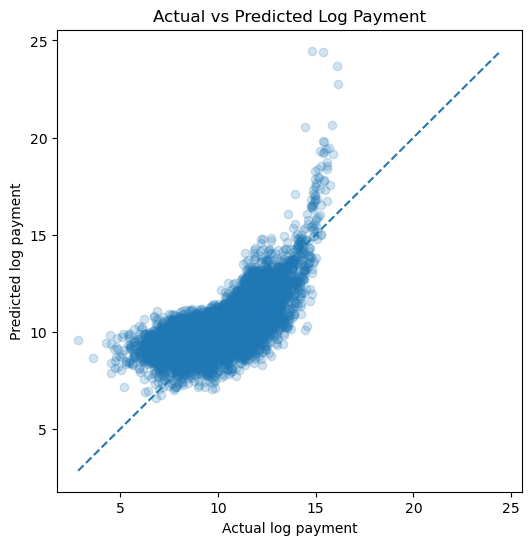

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_log, alpha=0.2)
plt.xlabel("Actual log payment")
plt.ylabel("Predicted log payment")
plt.title("Actual vs Predicted Log Payment")

# ideal line
mn = min(y_val.min(), y_pred_log.min())
mx = max(y_val.max(), y_pred_log.max())
plt.plot([mn, mx], [mn, mx], linestyle='--')

plt.show()

In [30]:
df_sample['log_Tot_Benes'] = np.log1p(df_sample['Tot_Benes'])
df_sample['log_Tot_Srvcs'] = np.log1p(df_sample['Tot_Srvcs'])
df_sample['log_Tot_Sbmtd_Chrg'] = np.log1p(df_sample['Tot_Sbmtd_Chrg'])
df_sample['log_Tot_Mdcr_Alowd_Amt'] = np.log1p(df_sample['Tot_Mdcr_Alowd_Amt'])

df_sample['srvcs_per_bene'] = df_sample['Tot_Srvcs'] / (df_sample['Tot_Benes'] + 1)
df_sample['allowed_per_service'] = df_sample['Tot_Mdcr_Alowd_Amt'] / (df_sample['Tot_Srvcs'] + 1)
df_sample['submitted_per_service'] = df_sample['Tot_Sbmtd_Chrg'] / (df_sample['Tot_Srvcs'] + 1)

In [31]:
print(df_sample[[
    'log_Tot_Benes',
    'log_Tot_Srvcs',
    'log_Tot_Sbmtd_Chrg',
    'log_Tot_Mdcr_Alowd_Amt',
    'srvcs_per_bene',
    'allowed_per_service',
    'submitted_per_service'
]].head())

   log_Tot_Benes  log_Tot_Srvcs  log_Tot_Sbmtd_Chrg  log_Tot_Mdcr_Alowd_Amt  \
0       4.094345       6.642487            8.678632                8.638687   
1       4.330733       5.068904           10.750985                9.774568   
2       4.174387       5.204007           10.679619                9.696335   
3       3.258097       4.605170            9.626152                9.204956   
4       6.927558       8.097122           13.354586               12.486372   

   srvcs_per_bene  allowed_per_service  submitted_per_service  
0       12.766667             7.359726               7.659713  
1        2.078947           110.565409             293.553459  
2        2.784615            89.323681             238.791209  
3        3.807692            99.453000             151.550000  
4        3.219608            80.579702             191.993607  


In [39]:
df_sample.head()

,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year,Tot_Mdcr_Pymt_Amt_log,log_Tot_Benes,log_Tot_Srvcs,log_Tot_Sbmtd_Chrg,log_Tot_Mdcr_Alowd_Amt,srvcs_per_bene,allowed_per_service,submitted_per_service
0,OH,VisionHearing,Y,6,59,766.0,5875.0,5644.91,3325.27,73,0.7680,2013,8.109607,4.094345,6.642487,8.678632,8.638687,12.766667,7.359726,7.659713
1,NJ,MedicalSpecialtyOther,Y,11,75,158.0,46675.0,17579.90,13911.10,67,1.3046,2013,9.540514,4.330733,5.068904,10.750985,9.774568,2.078947,110.565409,293.553459
2,NM,PrimaryCare,Y,12,64,181.0,43460.0,16256.91,12925.64,65,2.1357,2013,9.467046,4.174387,5.204007,10.679619,9.696335,2.784615,89.323681,238.791209
3,WA,PrimaryCare,Y,7,25,99.0,15155.0,9945.30,7286.85,75,0.8652,2013,8.893964,3.258097,4.605170,9.626152,9.204956,3.807692,99.453000,151.550000
4,MI,Cardiology,Y,70,1019,3284.0,630699.0,264704.32,203962.39,72,1.5869,2013,12.225696,6.927558,8.097122,13.354586,12.486372,3.219608,80.579702,191.993607


In [32]:
string_cols = df_sample.select_dtypes(include=['object']).columns.tolist()
print("String columns:", string_cols)

# one-hot encode them
df_encoded = pd.get_dummies(df_sample, columns=string_cols, drop_first=False)

print(df_encoded.shape)
print(df_encoded.head())

String columns: ['Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind']
(220000, 97)
   Tot_HCPCS_Cds  Tot_Benes  Tot_Srvcs  Tot_Sbmtd_Chrg  Tot_Mdcr_Alowd_Amt  \
0              6         59      766.0          5875.0             5644.91   
1             11         75      158.0         46675.0            17579.90   
2             12         64      181.0         43460.0            16256.91   
3              7         25       99.0         15155.0             9945.30   
4             70       1019     3284.0        630699.0           264704.32   

   Tot_Mdcr_Pymt_Amt  Bene_Avg_Age  Bene_Avg_Risk_Scre  year  \
0            3325.27            73              0.7680  2013   
1           13911.10            67              1.3046  2013   
2           12925.64            65              2.1357  2013   
3            7286.85            75              0.8652  2013   
4          203962.39            72              1.5869  2013   

   Tot_Mdcr_Pymt_Amt_log  ...  Rn

/tmp/ipykernel_43811/397641307.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_sample.select_dtypes(include=['object']).columns.tolist()


In [33]:
train_df = df_encoded[df_encoded['year'].between(2013, 2020)].copy()
val_df   = df_encoded[df_encoded['year'] == 2021].copy()
test_df  = df_encoded[df_encoded['year'].between(2022, 2023)].copy()

target = 'Tot_Mdcr_Pymt_Amt_log'

In [40]:
# drop leakage columns
drop_cols = [target, 'Tot_Mdcr_Pymt_Amt', 'year']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

print("Train:", X_train.shape, y_train.shape)
print("val :", X_val.shape, y_val.shape)

Train: (160000, 94) (160000,)
val : (20000, 94) (20000,)


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# fit model
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred_log = lr.predict(X_val)

In [37]:
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
mae_log = mean_absolute_error(y_val, y_pred_log)
r2_log = r2_score(y_val, y_pred_log)

print("RMSE (log scale):", rmse_log)
print("MAE  (log scale):", mae_log)
print("R^2  (log scale):", r2_log)

RMSE (log scale): 0.09386359830021257
MAE  (log scale): 0.0559853002550549
R^2  (log scale): 0.9960147284487892


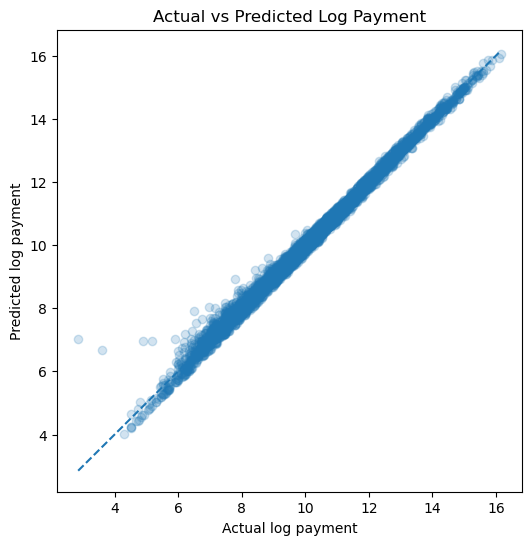

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_log, alpha=0.2)
plt.xlabel("Actual log payment")
plt.ylabel("Predicted log payment")
plt.title("Actual vs Predicted Log Payment")

# ideal line
mn = min(y_val.min(), y_pred_log.min())
mx = max(y_val.max(), y_pred_log.max())
plt.plot([mn, mx], [mn, mx], linestyle='--')

plt.show()

In [41]:
results_log = pd.DataFrame({
    'actual_log_payment': y_val,
    'predicted_log_payment': y_pred_log
})

print(results_log.head(10))

        actual_log_payment  predicted_log_payment
160000            9.485150               9.475122
160001           11.623487              11.649590
160002           13.137068              13.113263
160003            9.946543               9.918270
160004            7.185569               7.124960
160005           10.770850              10.763963
160006           11.349461              11.383769
160007           11.473642              11.505355
160008            8.578491               8.619883
160009            9.251856               9.205406


In [52]:
# drop leakage columns
drop_cols = [target, 'Tot_Mdcr_Pymt_Amt',
             'Tot_Mdcr_Alowd_Amt', 
             'log_Tot_Mdcr_Alowd_Amt',
             'allowed_per_service']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

print("Train:", X_train.shape, y_train.shape)
print("val :", X_val.shape, y_val.shape)

Train: (160000, 92) (160000,)
val : (20000, 92) (20000,)


In [53]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
y_pred_log = lr.predict(X_val)

In [55]:
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
mae_log = mean_absolute_error(y_val, y_pred_log)
r2_log = r2_score(y_val, y_pred_log)

print("RMSE (log scale):", rmse_log)
print("MAE  (log scale):", mae_log)
print("R^2  (log scale):", r2_log)

RMSE (log scale): 0.34566464262267943
MAE  (log scale): 0.26592608852675864
R^2  (log scale): 0.9459527703012758


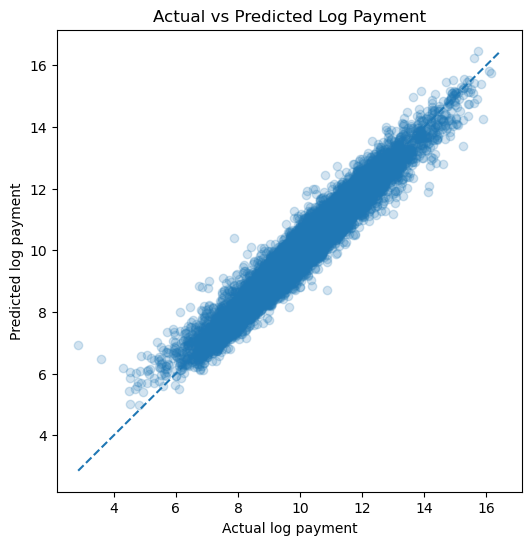

In [56]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_log, alpha=0.2)
plt.xlabel("Actual log payment")
plt.ylabel("Predicted log payment")
plt.title("Actual vs Predicted Log Payment")

# ideal line
mn = min(y_val.min(), y_pred_log.min())
mx = max(y_val.max(), y_pred_log.max())
plt.plot([mn, mx], [mn, mx], linestyle='--')

plt.show()

In [57]:
# drop leakage columns
drop_cols = [target, 'Tot_Mdcr_Pymt_Amt',
             'Tot_Mdcr_Alowd_Amt', 
             'log_Tot_Mdcr_Alowd_Amt',
             'allowed_per_service',
             'Tot_Sbmtd_Chrg',
             'log_Tot_Sbmtd_Chrg',
             'submitted_per_service']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

print("Train:", X_train.shape, y_train.shape)
print("val :", X_val.shape, y_val.shape)

Train: (160000, 89) (160000,)
val : (20000, 89) (20000,)


In [58]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [59]:
y_pred_log = lr.predict(X_val)

In [60]:
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
mae_log = mean_absolute_error(y_val, y_pred_log)
r2_log = r2_score(y_val, y_pred_log)

print("RMSE (log scale):", rmse_log)
print("MAE  (log scale):", mae_log)
print("R^2  (log scale):", r2_log)

RMSE (log scale): 0.5080637940504565
MAE  (log scale): 0.3617261988506271
R^2  (log scale): 0.8832384060627274


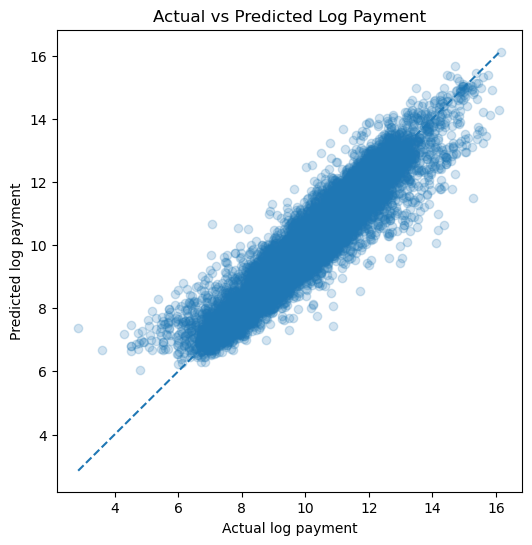

In [61]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_log, alpha=0.2)
plt.xlabel("Actual log payment")
plt.ylabel("Predicted log payment")
plt.title("Actual vs Predicted Log Payment")

# ideal line
mn = min(y_val.min(), y_pred_log.min())
mx = max(y_val.max(), y_pred_log.max())
plt.plot([mn, mx], [mn, mx], linestyle='--')

plt.show()

In [63]:
# keep only raw + ratio columns
drop_cols = [target, 'Tot_Mdcr_Pymt_Amt',
             'log_Tot_Benes',
             'log_Tot_Srvcs',
             'log_Tot_Sbmtd_Chrg',
             'log_Tot_Mdcr_Alowd_Amt']
             

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

print("Train:", X_train.shape, y_train.shape)
print("val :", X_val.shape, y_val.shape)

Train: (160000, 91) (160000,)
val : (20000, 91) (20000,)


In [64]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
y_pred_log = lr.predict(X_val)

In [66]:
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
mae_log = mean_absolute_error(y_val, y_pred_log)
r2_log = r2_score(y_val, y_pred_log)

print("RMSE (log scale):", rmse_log)
print("MAE  (log scale):", mae_log)
print("R^2  (log scale):", r2_log)

RMSE (log scale): 1.0597936180698253
MAE  (log scale): 0.8124512274054728
R^2  (log scale): 0.4919503918471344


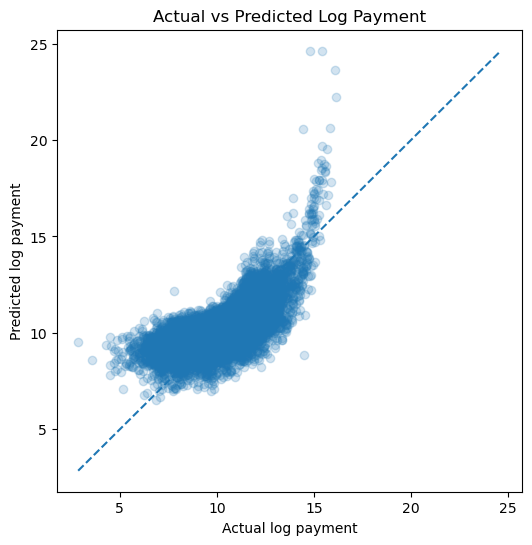

In [67]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_log, alpha=0.2)
plt.xlabel("Actual log payment")
plt.ylabel("Predicted log payment")
plt.title("Actual vs Predicted Log Payment")

# ideal line
mn = min(y_val.min(), y_pred_log.min())
mx = max(y_val.max(), y_pred_log.max())
plt.plot([mn, mx], [mn, mx], linestyle='--')

plt.show()